In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Задача 1. Колл-центр и экспоненциальное распределение

Случайная величина *X*  показывает, сколько минут один сотрудник кол-центра потратил на одного клиента.

Случайная величина *Y*  показывает, сколько минут проходит между звонками в кол-центре.

Пусть $X$ и $Y$ — экспоненциально распределённые случайные величины.

Среднее время между звонками в кол-центр — $8$ минут.

 1. Какова вероятность, что следующий звонок произойдет в течение $5$ минут?

 2. Какова вероятность, что время между звонками будет от $10$ до $15$ минут?

 3. Какова вероятность, что время между звонками составит ровно $8$ минут?


In [ ]:
from scipy.stats import expon

1/$\lambda$ = среднее время

In [ ]:
scale = 8

**Пункт 1**

In [ ]:
t = 5
prob_less_5 = expon.cdf(t, scale=scale)
print(f"Вероятность звонка ≤ 5 минут: {prob_less_5:.4f}")

Вероятность звонка ≤ 5 минут: 0.4647


In [ ]:
# график плотности для P(Y <= 5)
x = np.linspace(0, 30, 500)
y_pdf = expon.pdf(x, scale=scale)
y_cdf = expon.cdf(x, scale=scale)

x_fill = np.linspace(0, t, 200)
y_fill_pdf = expon.pdf(x_fill, scale=scale)

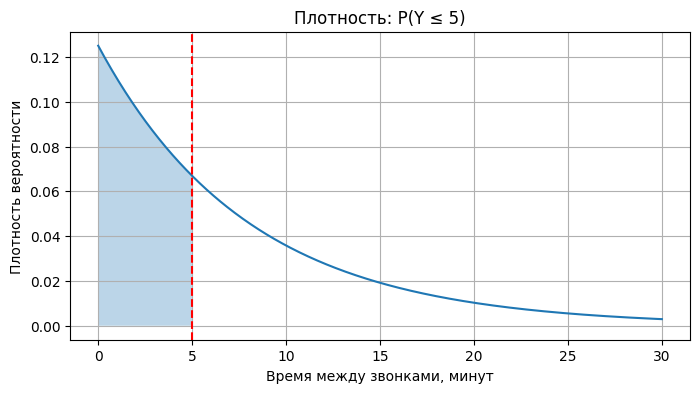

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(x, y_pdf)
plt.axvline(t, color = 'red', linestyle='--')
plt.fill_between(x_fill, y_fill_pdf, alpha=0.3)
plt.title(f'Плотность: P(Y ≤ {t})')
plt.xlabel('Время между звонками, минут')
plt.ylabel('Плотность вероятности')
plt.grid()
plt.show()

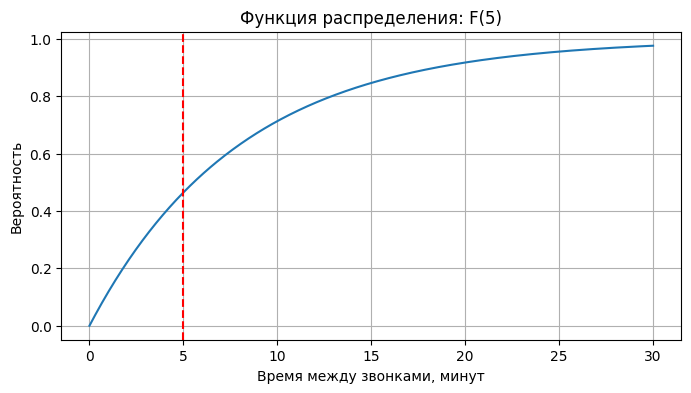

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(x, y_cdf)
plt.axvline(t, color='red', linestyle='--')
plt.title(f'Функция распределения: F({t})')
plt.xlabel('Время между звонками, минут')
plt.ylabel('Вероятность')
plt.grid()
plt.show()

**Пункт 2**

In [ ]:
a = 10
b = 15
prob_10_to_15 = expon.cdf(b, scale=scale) - expon.cdf(a, scale=scale)
print(f"Вероятность 10-15 минут между звонками: {prob_10_to_15:.4f}")

Вероятность 10-15 минут между звонками: 0.1331


In [ ]:
lower_bound = 10
upper_bound = 15

In [ ]:
x = np.linspace(0, 30, 500)
y_pdf = expon.pdf(x, scale=scale)
y_cdf = expon.cdf(x, scale=scale)

x_fill = np.linspace(lower_bound, upper_bound, 200)
y_fill_pdf = expon.pdf(x_fill, scale=scale)

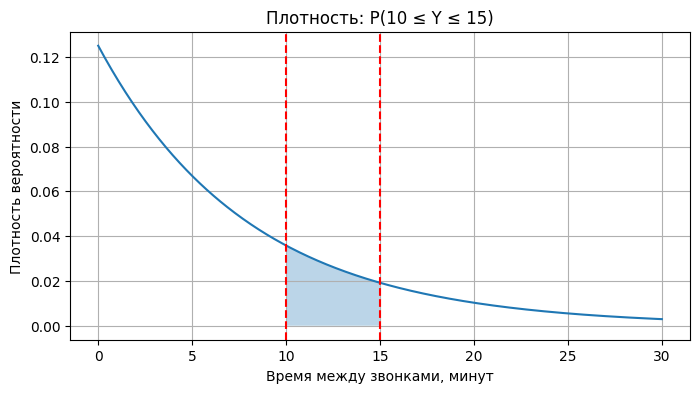

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(x, y_pdf)
plt.axvline(lower_bound, color='red', linestyle='--')
plt.axvline(upper_bound, color='red', linestyle='--')
plt.fill_between(x_fill, y_fill_pdf, alpha=0.3)
plt.title(f'Плотность: P({lower_bound} ≤ Y ≤ {upper_bound})')
plt.xlabel('Время между звонками, минут')
plt.ylabel('Плотность вероятности')
plt.grid()
plt.show()

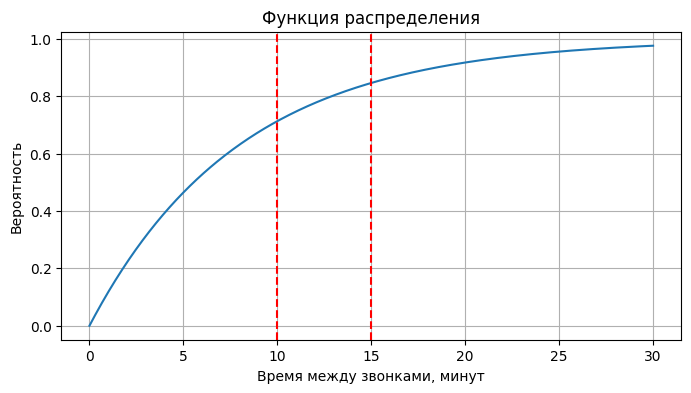

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(x, y_cdf)
plt.axvline(lower_bound, color='red', linestyle='--')
plt.axvline(upper_bound, color='red', linestyle='--')
plt.title(f'Функция распределения')
plt.xlabel('Время между звонками, минут')
plt.ylabel('Вероятность')
plt.grid()
plt.show()

**Пункт 3**

Вероятность равна нулю, так как экспоненциальное распределение непрерывно.

# Задача 2. Оптимизация курьерской нагрузки

Вы продуктовый аналитик в сервисе доставки еды.

Команда операций жалуется, что курьеры то простаивают, то не справляются с наплывом заказов. А клиенты жалуются на долгое ожидание, особенно в «часы пик».

- Для количества заказов за период времени (т.е. **час**) используем **распределение Пуассона** с параметром $\lambda=5$.

- Время доставки одного заказа курьером **распределено экспоненциально** и занимает в среднем 30 минут.


## Пункт 1

Спрогнозируй вероятность, что в следующий час:

 1\) будет не больше 3 заказов (риск простоя);

 2\) будет больше 7 заказов (риск перегрузки);

 3\) что новый заказ придёт в течение 5 минут после предыдущего?

In [ ]:
from scipy.stats import poisson, expon

In [ ]:
orders_lambda = 5
pois_dist = poisson(mu=orders_lambda)

In [ ]:
print(pois_dist)
print(type(pois_dist))

<class 'scipy.stats._distn_infrastructure.rv_discrete_frozen'>


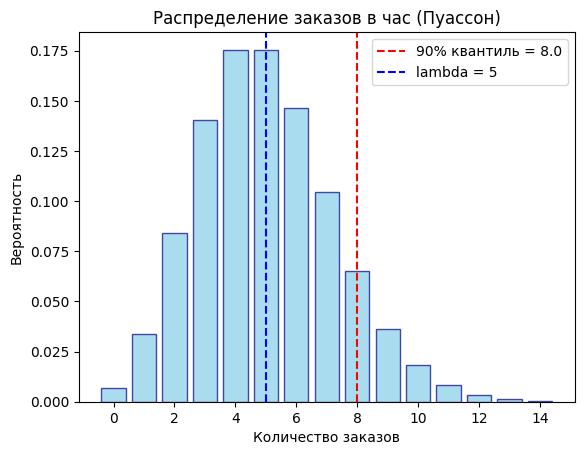

In [ ]:
# График распределения Пуассона
x_pois = np.arange(0, 15)
bars = plt.bar(x_pois, pois_dist.pmf(x_pois), color='skyblue', edgecolor='navy', alpha=0.7)

# Отмечаем 90% квантиль
pois_90 = pois_dist.ppf(0.9)
plt.axvline(pois_90, color='red', linestyle='--', label=f'90% квантиль = {pois_90}')
plt.axvline(orders_lambda, color='blue', linestyle='--', label=f'lambda = {orders_lambda}')

plt.title('Распределение заказов в час (Пуассон)')
plt.xlabel('Количество заказов')
plt.ylabel('Вероятность')
plt.legend()
plt.show()

Рассчитаем вероятность *простоя*.

In [ ]:
prob_underload = pois_dist.cdf(3)
print(prob_underload)

0.2650259152973616


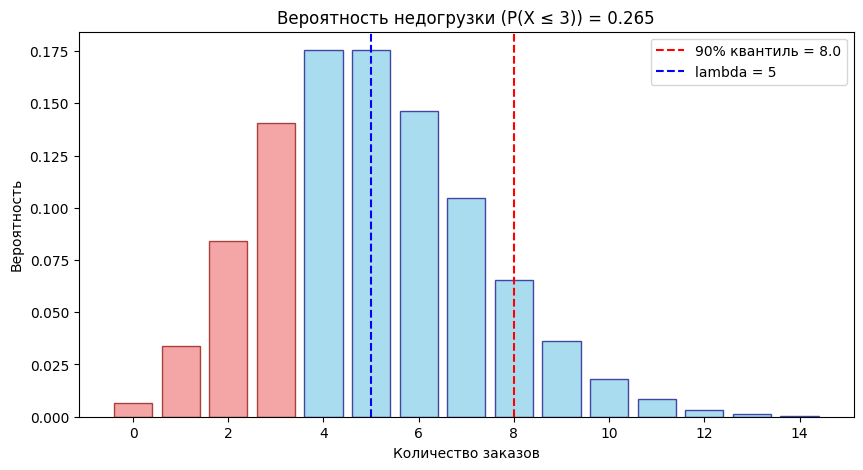

In [ ]:
# Первый график: prob_underload = pois_dist.cdf(3)
plt.figure(figsize=(10, 5))
x_pois = np.arange(0, 15)
bars = plt.bar(x_pois, pois_dist.pmf(x_pois), color='skyblue', edgecolor='navy', alpha=0.7)

# Закрашиваем столбцы для prob_underload (x ≤ 3)
for bar in bars[:4]:  # 0, 1, 2, 3
    bar.set_color('lightcoral')
    bar.set_edgecolor('darkred')
    bar.set_alpha(0.7)

# Добавляем линии для квантили и lambda
plt.axvline(pois_dist.ppf(0.9), color='red', linestyle='--', label=f'90% квантиль = {pois_dist.ppf(0.9):.1f}')
plt.axvline(orders_lambda, color='blue', linestyle='--', label=f'lambda = {orders_lambda}')

plt.title('Вероятность недогрузки (P(X ≤ 3)) = {:.3f}'.format(pois_dist.cdf(3)))
plt.xlabel('Количество заказов')
plt.ylabel('Вероятность')
plt.legend()
plt.show()

Рассчитаем вероятность *перезагрузки*.

In [ ]:
prob_overload = 1 - pois_dist.cdf(7)
print(prob_overload)

0.1333716740700075


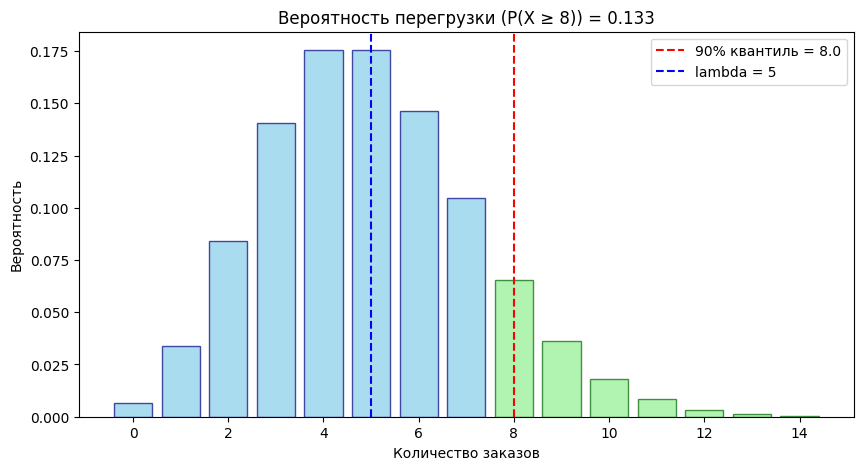

In [ ]:
# Второй график: prob_overload = 1 - pois_dist.cdf(7)
plt.figure(figsize=(10, 5))
bars = plt.bar(x_pois, pois_dist.pmf(x_pois), color='skyblue', edgecolor='navy', alpha=0.7)

# Закрашиваем столбцы для prob_overload (x ≥ 8)
for bar in bars[8:]:  # 8, 9, 10, ...
    bar.set_color('lightgreen')
    bar.set_edgecolor('darkgreen')
    bar.set_alpha(0.7)

# Добавляем линии для квантили и lambda
plt.axvline(pois_dist.ppf(0.9), color='red', linestyle='--', label=f'90% квантиль = {pois_dist.ppf(0.9):.1f}')
plt.axvline(orders_lambda, color='blue', linestyle='--', label=f'lambda = {orders_lambda}')

plt.title('Вероятность перегрузки (P(X ≥ 8)) = {:.3f}'.format(1 - pois_dist.cdf(7)))
plt.xlabel('Количество заказов')
plt.ylabel('Вероятность')
plt.legend()
plt.show()

Теперь перейдём к **экспоненциальному распределению**.

In [ ]:
mean_time = 12
exp_dist = expon(scale=mean_time)

Рассчитаем вероятность заказа в первые 5 минут.

In [ ]:
prob_5min = exp_dist.cdf(5)
print(prob_5min)

0.34075936979955623


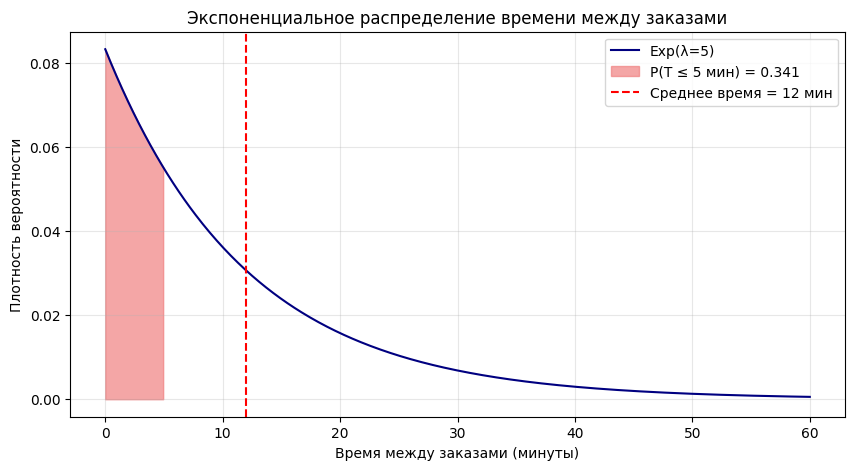

Вероятность, что время между заказами ≤ 5 минут: 0.341


In [ ]:
time = np.linspace(0, 60, 500)
pdf = exp_dist.pdf(time)  # Функция плотности вероятности (PDF)

# Строим график плотности
plt.figure(figsize=(10, 5))
plt.plot(time, pdf, color='navy', label=f'Exp(λ=5)')

# Закрашиваем область P(T ≤ 5 минут)
mask = time <= 5
plt.fill_between(time[mask], pdf[mask], color='lightcoral', alpha=0.7, label=f'P(T ≤ 5 мин) = {exp_dist.cdf(5):.3f}')

# Отмечаем среднее время (12 минут)
plt.axvline(mean_time, color='red', linestyle='--', label=f'Среднее время = {mean_time} мин')

plt.title('Экспоненциальное распределение времени между заказами')
plt.xlabel('Время между заказами (минуты)')
plt.ylabel('Плотность вероятности')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Выводим P(T ≤ 5 минут)
print(f"Вероятность, что время между заказами ≤ 5 минут: {exp_dist.cdf(5):.3f}")

## Пункт 2

Компания хочет оптимизировать количество курьеров так, чтобы вероятность того, что заказ будет ждать курьера дольше 10 минут, была меньше 20%.


In [ ]:
orders_lambda = 5  # Среднее число заказов в час
delivery_mean_time = 30  # Среднее время доставки (минут)
max_waiting_time = 10  # Максимальное допустимое время ожидания (минут)
target_prob = 0.2  # Целевая вероятность превышения max_waiting_time
n_couriers_range = range(1, 11)  # Проверяем от 1 до 10 курьеров

Предположим, что у нас 2 курьера.

Посмотрим, сколько получится заказов и суммарного времени ожидания на горизонте 1000 часов.

In [ ]:
n_couriers = 2 # 3 курьера

In [ ]:

# Генерация заказов

n_hours = 1000
np.random.seed(10)
orders_per_hour = poisson(mu=orders_lambda).rvs(n_hours)

print(type(orders_per_hour))
print(orders_per_hour[:5])
print(len(orders_per_hour))

<class 'numpy.ndarray'>
[4 3 3 8 7]
1000


In [ ]:
total_orders = np.sum(orders_per_hour)

print(total_orders)

4843


Для каждого из 1000 часов генерируется количество заказов из распределения Пуассона со средним orders_lambda = 5.

Например:

orders_per_hour[0] = 4 → в первый час пришло 4 заказа;

orders_per_hour[1] = 6 → во второй час пришло 6 заказов.
total_orders — общее количество заказов за 1000 часов (например, 5000).

In [ ]:
# Генерация времени между заказами
interarrival_times = expon(scale=60 / orders_lambda).rvs(total_orders)

print(type(interarrival_times))
print(interarrival_times[:5])
print(len(interarrival_times))

<class 'numpy.ndarray'>
[42.13817104  2.15807699  0.76398668 36.42809754  0.10180018]
4843


Генерируются времена между заказами (в минутах) из экспоненциального распределения.

scale = 60 / 5 = 12 означает, что в среднем заказы приходят каждые 12 минут.

Например:

interarrival_times[0] = 8.2 → первый заказ пришёл через 8,2 минуты после старта;

interarrival_times[1] = 15.1 → второй заказ пришёл через 15,1 минуты после первого.

In [ ]:
# Генерация времени доставки
delivery_times = expon(scale=delivery_mean_time).rvs(total_orders)

print(type(delivery_times))
print(delivery_times[:5])
print(len(delivery_times))

<class 'numpy.ndarray'>
[54.64834022  8.80237424 42.43828115 15.07896498 72.76098495]
4843


Для каждого заказа генерируется время доставки (в минутах) из экспоненциального распределения со средним 30 минут.

Например:

delivery_times[0] = 25.3 → первый заказ будет доставляться 25,3 минуты;

delivery_times[1] = 42.1 → второй заказ будет доставляться 42,1 минуты.

In [ ]:
arrival_times = np.cumsum(interarrival_times)  # Моменты поступления заказов

print(type(arrival_times))
print(arrival_times[:5])
print(len(arrival_times))

<class 'numpy.ndarray'>
[42.13817104 44.29624802 45.0602347  81.48833225 81.59013242]
4843


In [ ]:
courier_busy_until = np.zeros(n_couriers)  # Когда каждый курьер освободится

print(type(courier_busy_until))
print(courier_busy_until[:5])
print(len(courier_busy_until))

<class 'numpy.ndarray'>
[0. 0.]
2


In [ ]:
waiting_times = []  # Время ожидания для каждого заказа

Обработаем первый заказ.

In [ ]:
arrival = arrival_times[0]
print(arrival)

earliest_free = np.min(courier_busy_until)
print(earliest_free)

courier_idx = np.argmin(courier_busy_until)
print(courier_idx)

waiting_time = max(0, earliest_free - arrival)
waiting_times.append(waiting_time)

courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[0]

42.138171035472936
0.0
0


Обработаем второй заказ.

In [ ]:
arrival = arrival_times[1]
print(arrival)

earliest_free = np.min(courier_busy_until)
print(earliest_free)

courier_idx = np.argmin(courier_busy_until)
print(courier_idx)

waiting_time = max(0, earliest_free - arrival)
waiting_times.append(waiting_time)

courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[1]

44.29624802301693
0.0
1


Обработаем третий заказ.

In [ ]:
arrival = arrival_times[2]
print(arrival)

earliest_free = np.min(courier_busy_until)
print(earliest_free)

courier_idx = np.argmin(courier_busy_until)
print(courier_idx)

waiting_time = max(0, earliest_free - arrival)
waiting_times.append(waiting_time)

courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[2]

45.060234704586506
53.098622267494974
1


In [ ]:
print(waiting_times)

[0, 0, np.float64(8.038387562908468)]


Обработаем четвёртый заказ.

In [ ]:
arrival = arrival_times[3]
print(arrival)

earliest_free = np.min(courier_busy_until)
print(earliest_free)

courier_idx = np.argmin(courier_busy_until)
print(courier_idx)

waiting_time = max(0, earliest_free - arrival)
waiting_times.append(waiting_time)

courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[3]

81.48833224854839
95.5369034142823
1


In [ ]:
print(waiting_times)

[0, 0, np.float64(8.038387562908468), np.float64(14.048571165733918)]


Соберём в единый код и пройдёмся по всем параметрам.

In [ ]:
# Параметры
orders_lambda = 5  # 5 заказов/час
delivery_mean_time = 30  # 30 мин/заказ
max_waiting_time = 10  # 10 мин макс. ожидание
n_couriers = 3  # 3 курьера
n_hours = 1000  # 1000 часов моделирования

# Генерация заказов
orders_per_hour = poisson(mu=orders_lambda).rvs(n_hours)
total_orders = np.sum(orders_per_hour)

# Время между заказами и время доставки
interarrival_times = expon(scale=60/orders_lambda).rvs(total_orders)
delivery_times = expon(scale=delivery_mean_time).rvs(total_orders)

# Моделирование
arrival_times = np.cumsum(interarrival_times)
courier_busy_until = np.zeros(n_couriers)
waiting_times = []

for i in range(total_orders):
    arrival = arrival_times[i]
    earliest_free = np.min(courier_busy_until)
    courier_idx = np.argmin(courier_busy_until)
    waiting_time = max(0, earliest_free - arrival)
    waiting_times.append(waiting_time)

    courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[i]

In [ ]:
print(waiting_times[:10])

[0, 0, 0, 0, np.float64(4.107586096121089), np.float64(6.878025325604618), np.float64(17.317157033418837), np.float64(39.4738108117041), np.float64(32.171389477431916), np.float64(29.44706849786627)]


In [ ]:
# Расчёт метрик
prob_over_wait = np.mean(np.array(waiting_times) > max_waiting_time)

print(prob_over_wait)

0.5625380093249543


In [ ]:
courier_utilization = np.sum(delivery_times) / (n_couriers * n_hours * 60)

print(courier_utilization)

0.8165371398737867


Теперь настроим численный метод для итерирования по различным количествам курьеров.

In [ ]:
results = []

# Перебираем разное количество курьеров
for n_couriers in n_couriers_range:

    # Генерация заказов
    n_hours = 1000
    orders_per_hour = poisson(mu=orders_lambda).rvs(n_hours)
    total_orders = np.sum(orders_per_hour)

    # Генерация времени между заказами
    interarrival_times = expon(scale=60 / orders_lambda).rvs(total_orders)

    # Генерация времени доставки
    delivery_times = expon(scale=delivery_mean_time).rvs(total_orders)

    # Моделирование очереди
    arrival_times = np.cumsum(interarrival_times)
    courier_busy_until = np.zeros(n_couriers)
    waiting_times = []

    for i in range(total_orders):
        arrival = arrival_times[i]
        earliest_free = np.min(courier_busy_until)
        courier_idx = np.argmin(courier_busy_until)

        waiting_time = max(0, earliest_free - arrival)
        waiting_times.append(waiting_time)

        courier_busy_until[courier_idx] = max(arrival, earliest_free) + delivery_times[i]

    # Расчёт метрик
    prob_over_wait = np.mean(np.array(waiting_times) > max_waiting_time)
    courier_utilization = np.sum(delivery_times) / (n_couriers * n_hours * 60)

    # Сохраняем результаты
    results.append({
        'n_couriers': n_couriers,
        'prob_over_wait': prob_over_wait,
        'utilization': courier_utilization
    })

In [ ]:
results

[{'n_couriers': 1,
  'prob_over_wait': np.float64(0.999802488643097),
  'utilization': np.float64(2.4713498771083)},
 {'n_couriers': 2,
  'prob_over_wait': np.float64(0.9993890020366599),
  'utilization': np.float64(1.196694339162983)},
 {'n_couriers': 3,
  'prob_over_wait': np.float64(0.60761022750151),
  'utilization': np.float64(0.8223123112622304)},
 {'n_couriers': 4,
  'prob_over_wait': np.float64(0.18789101917255296),
  'utilization': np.float64(0.6120327887345816)},
 {'n_couriers': 5,
  'prob_over_wait': np.float64(0.05302435192458759),
  'utilization': np.float64(0.5009665102708615)},
 {'n_couriers': 6,
  'prob_over_wait': np.float64(0.01072961373390558),
  'utilization': np.float64(0.4315587862457774)},
 {'n_couriers': 7,
  'prob_over_wait': np.float64(0.0032639738882088943),
  'utilization': np.float64(0.35870780183939815)},
 {'n_couriers': 8,
  'prob_over_wait': np.float64(0.0008027292795504716),
  'utilization': np.float64(0.3126110695931281)},
 {'n_couriers': 9,
  'prob_ov

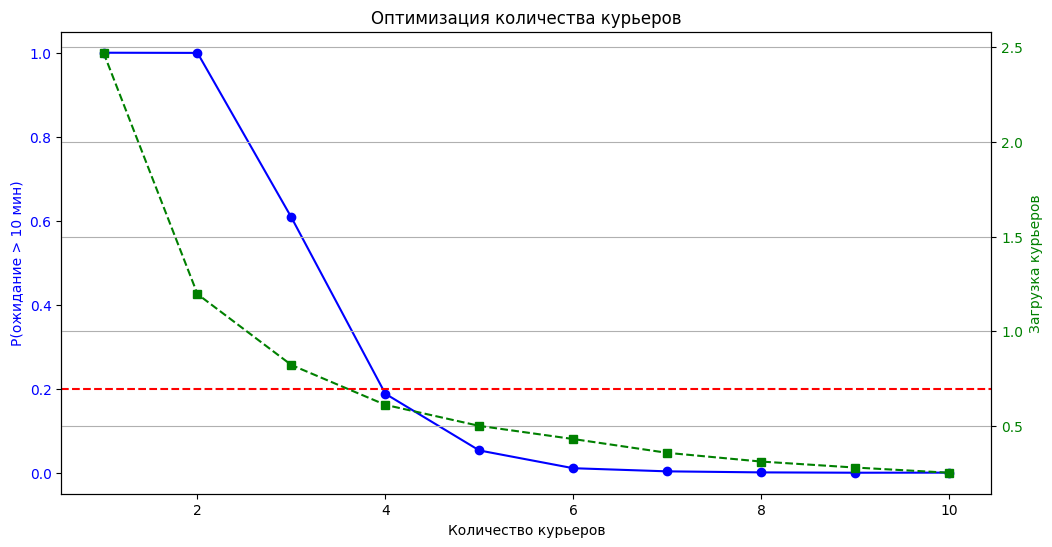

In [ ]:
# Подготовка данных для графиков
n_couriers_list = []
prob_over_wait_list = []
utilization_list = []

for r in results:
    n_couriers_list.append(r['n_couriers'])
    prob_over_wait_list.append(r['prob_over_wait'])
    utilization_list.append(r['utilization'])

# Создание графика
plt.figure(figsize=(12, 6))

# Первый график (вероятность ожидания)
ax1 = plt.gca()  # Получаем текущую ось
line1, = ax1.plot(n_couriers_list, prob_over_wait_list, 'o-', color='blue', label='Вероятность долгого ожидания')
ax1.set_xlabel('Количество курьеров')
ax1.set_ylabel('P(ожидание > 10 мин)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Горизонтальная линия цели
target_line = ax1.axhline(target_prob, color='red', linestyle='--', label='Целевой уровень (20%)')

# Вторая ось (загрузка курьеров)
ax2 = ax1.twinx()
line2, = ax2.plot(n_couriers_list, utilization_list, 's--', color='green', label='Загрузка курьеров')
ax2.set_ylabel('Загрузка курьеров', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Оптимизация количества курьеров')
plt.grid(True)
plt.show()

**Как определить оптимум?**

# Задача 3. Время сборки нескольких заказов

В продуктовых задачах экспоненциальное распределение часто используют для времени до завершения одного события: обработки заявки, сборки заказа или ожидания ответа. Если такие времена независимы и имеют одно и то же экспоненциальное распределение, их сумма имеет гамма-распределение.

В этой задаче время сборки одного заказа $X_i$ имеет экспоненциальное распределение со средним 3.75 минуты:

$$
X_i \sim \operatorname{Exp}(\lambda), \qquad \frac{1}{\lambda}=3.75
$$

Заказы собираются последовательно, времена сборки разных заказов независимы.

Нас интересует общее время сборки четырёх заказов:

$$
S_4 = X_1 + X_2 + X_3 + X_4
$$

Сумма четырёх независимых экспоненциальных случайных величин имеет гамма-распределение:

$$
S_4 \sim \operatorname{Gamma}(k=4,\theta=3.75)
$$

Если сборка четырёх заказов занимает больше 20 минут, сервис выплачивает клиентам суммарно 400 ₽ компенсации.

Нужно:

1. найти вероятность успеть собрать четыре заказа за 20 минут
2. найти вероятность, что сборка четырёх заказов займёт от 10 до 20 минут
3. найти время, в которое укладывается сборка четырёх заказов в 90% случаев
4. найти ожидаемый размер компенсации
5. визуализировать распределение и выделить область, соответствующую сборке за 20 минут

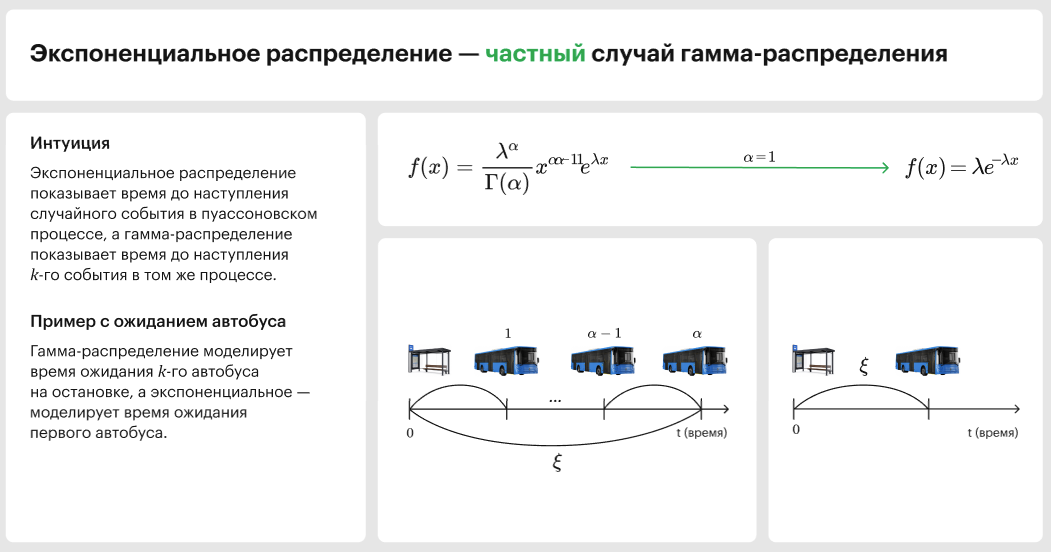

**Решение**

## Параметры распределения

Для суммы независимых экспоненциальных случайных величин параметр $k$ равен количеству слагаемых, а $\theta$ — среднему времени одного заказа.

В этой задаче $k=4$, а $\theta=3.75$. В `scipy.stats.gamma` параметр `a` соответствует $k$, а параметр `scale` соответствует $\theta$.

In [ ]:
from scipy.stats import gamma

In [ ]:
k = 4
theta = 3.75

rv = gamma(a=k, scale=theta)

## Пункт 1. Вероятность успеть собрать четыре заказа за 20 минут

Нас интересует событие:

$$
S_4 \leq 20
$$

Функция `cdf()` возвращает площадь под плотностью слева от выбранной границы. В этой задаче это вероятность:

$$
\mathbb{P}(S_4 \leq 20)
$$

In [ ]:
p_in_time = rv.cdf(20)

print("Вероятность собрать четыре заказа за 20 минут:", round(p_in_time, 4))

Вероятность собрать четыре заказа за 20 минут: 0.7787


Вероятность успеть собрать четыре заказа за 20 минут равна примерно **0.7787**, или **77.87%**.

## Пункт 2. Вероятность сборки от 10 до 20 минут

Нас интересует событие:

$$
10 \leq S_4 \leq 20
$$

Функция распределения $F(t)$ показывает вероятность получить значение не больше $t$. Поэтому вероятность попасть в промежуток равна разности двух накопленных вероятностей:

$$
\mathbb{P}(10 \leq S_4 \leq 20)
=
F(20) - F(10)
$$

In [ ]:
p_10_to_20 = rv.cdf(20) - rv.cdf(10)

print("Вероятность сборки четырёх заказов от 10 до 20 минут:", round(p_10_to_20, 4))

Вероятность сборки четырёх заказов от 10 до 20 минут: 0.5001


Вероятность равна примерно **0.5001**, или **50.01%**.

## Пункт 3. Время, в которое укладывается сборка четырёх заказов в 90% случаев

Нужно найти такое время $t$, что:

$$
\mathbb{P}(S_4 \leq t) = 0.9
$$

Такое значение называется 90-м перцентилем. Функция `ppf()` выполняет обратную операцию к `cdf()`: по вероятности возвращает соответствующий порог.

In [ ]:
time_90 = rv.ppf(0.9)

print("90-й перцентиль:", round(time_90, 2), "минуты")

90-й перцентиль: 25.05 минуты


Получаем примерно **25.05 минуты**.

В 90% случаев четыре заказа будут собраны не дольше чем за 25 минут.

## Пункт 4. Ожидаемый размер компенсации

Вероятность того, что сборка четырёх заказов займёт больше 20 минут:

$$
\mathbb{P}(S_4 > 20) = 1 - \mathbb{P}(S_4 \leq 20)
$$

Ожидаемый размер компенсации равен вероятности задержки, умноженной на 400 рублей.


In [ ]:
p_delay = 1 - p_in_time

expected_compensation = 400 * p_delay

print("Ожидаемые расходы на компенсацию:", round(expected_compensation, 2), "рублей")


Ожидаемые расходы на компенсацию: 88.52 рублей


Ожидаемые расходы на компенсацию составляют примерно **88.52 рубля** на четыре заказа.


## Пункт 5. Визуализация распределения

Построим плотность гамма-распределения.

Площадь закрашенной области слева от 20 минут равна вероятности успеть собрать четыре заказа за это время.

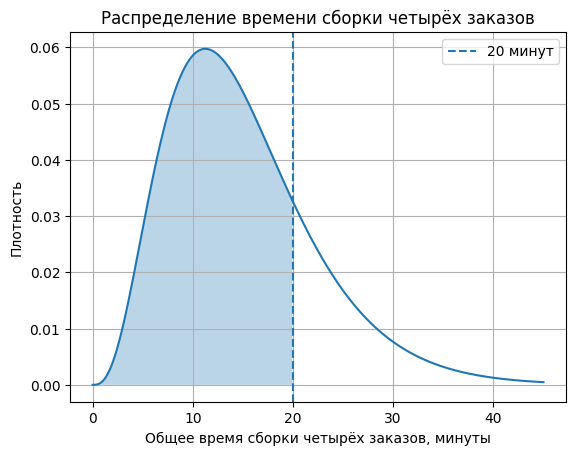

In [ ]:
x = np.linspace(0, 45, 500)
density = rv.pdf(x)

plt.plot(x, density)

in_time_x = x[x <= 20]
in_time_density = rv.pdf(in_time_x)

plt.fill_between(
    in_time_x,
    in_time_density,
    alpha=0.3
)

plt.axvline(
    20,
    linestyle="--",
    label="20 минут"
)

plt.xlabel("Общее время сборки четырёх заказов, минуты")
plt.ylabel("Плотность")
plt.title("Распределение времени сборки четырёх заказов")
plt.legend()
plt.grid()
plt.show()

# Задача 4. Познакомимся с бета-распределением


Если

$$
X\sim Beta(\alpha,\beta)
$$

то плотность распределения имеет вид

$$
f(x)
=
\frac{x^{\alpha-1}(1-x)^{\beta-1}}
{B(\alpha,\beta)},
\quad 0<x<1
$$

Бета-функция нужна для того, чтобы площадь под плотностью распределения была равна $1$.

**Бета-функция** — функция двух положительных параметров, которая часто встречается в теории вероятностей и математической статистике.

Она определяется как

$$
B(\alpha,\beta)
=
\int_0^1
x^{\alpha-1}(1-x)^{\beta-1}\,dx
$$

где $\alpha>0$ и $\beta>0$.

Бета-функция тесно связана с гамма-функцией:

$$
B(\alpha,\beta)
=
\frac{\Gamma(\alpha)\Gamma(\beta)}
{\Gamma(\alpha+\beta)}
$$

Это позволяет вычислять бета-функцию через гамма-функцию.

Если $\alpha$ и $\beta$ — положительные целые числа, то можно использовать связь гамма-функции с факториалом:

$$
B(m,n)
=
\frac{(m-1)!(n-1)!}
{(m+n-1)!}
$$

Например,

$$
B(2,3)
=
\frac{1!\,2!}{4!}
=
\frac{1}{12}
$$

Ещё одно важное свойство — симметричность:

$$
B(\alpha,\beta)=B(\beta,\alpha)
$$

Например,

$$
B(2,5)=B(5,2)
$$

Бета-функция используется как **нормирующий множитель** в бета-распределении.


## Функция плотности бета распределения

**Визуализируем плотность бета-распределения для разных значений параметров.**

Параметры $\alpha$ и $\beta$ определяют форму распределения.

В отличие от гамма-распределения, бета-распределение определено только на отрезке от $0$ до $1$. Поэтому его удобно использовать для моделирования вероятностей, долей и других величин, ограниченных этим диапазоном.

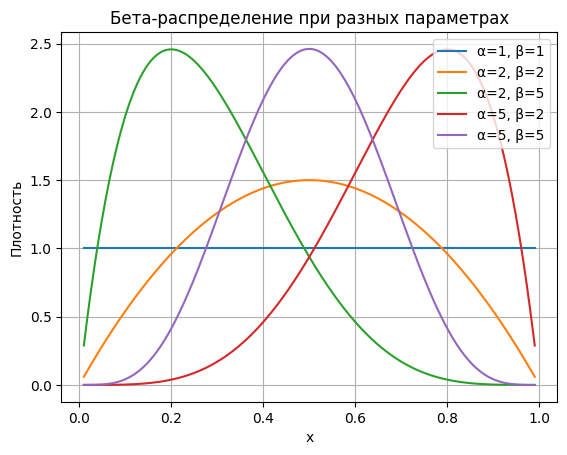

In [ ]:
from scipy.stats import beta

x = np.linspace(0.01, 0.99, 500)

params = [
    (1, 1),
    (2, 2),
    (2, 5),
    (5, 2),
    (5, 5)
]

for alpha, beta_param in params:
    pdf = beta.pdf(
        x,
        a=alpha,
        b=beta_param
    )

    plt.plot(
        x,
        pdf,
        label=f"α={alpha}, β={beta_param}"
    )

plt.xlabel("x")
plt.ylabel("Плотность")
plt.title("Бета-распределение при разных параметрах")
plt.legend()
plt.grid()
plt.show()

## Основные свойства бета-функции и бета-распределения

- Бета-функция зависит от двух положительных параметров $\alpha$ и $\beta$
- Она симметрична: $B(\alpha,\beta)=B(\beta,\alpha)$
- Бета-функция связана с гамма-функцией через $\Gamma(\alpha)$ и $\Gamma(\beta)$
- В бета-распределении она используется для нормировки плотности
- При $\alpha=\beta=1$ бета-распределение превращается в равномерное распределение на $(0,1)$
- При $\alpha=\beta>1$ распределение симметрично относительно $0.5$
- Если $\alpha>\beta$, большая часть плотности смещается вправо
- Если $\alpha<\beta$, большая часть плотности смещается влево

Бета-распределение удобно использовать для моделирования **вероятностей и долей**. Например, с его помощью можно описывать неизвестную вероятность успеха, которая может принимать значения только от $0$ до $1$.

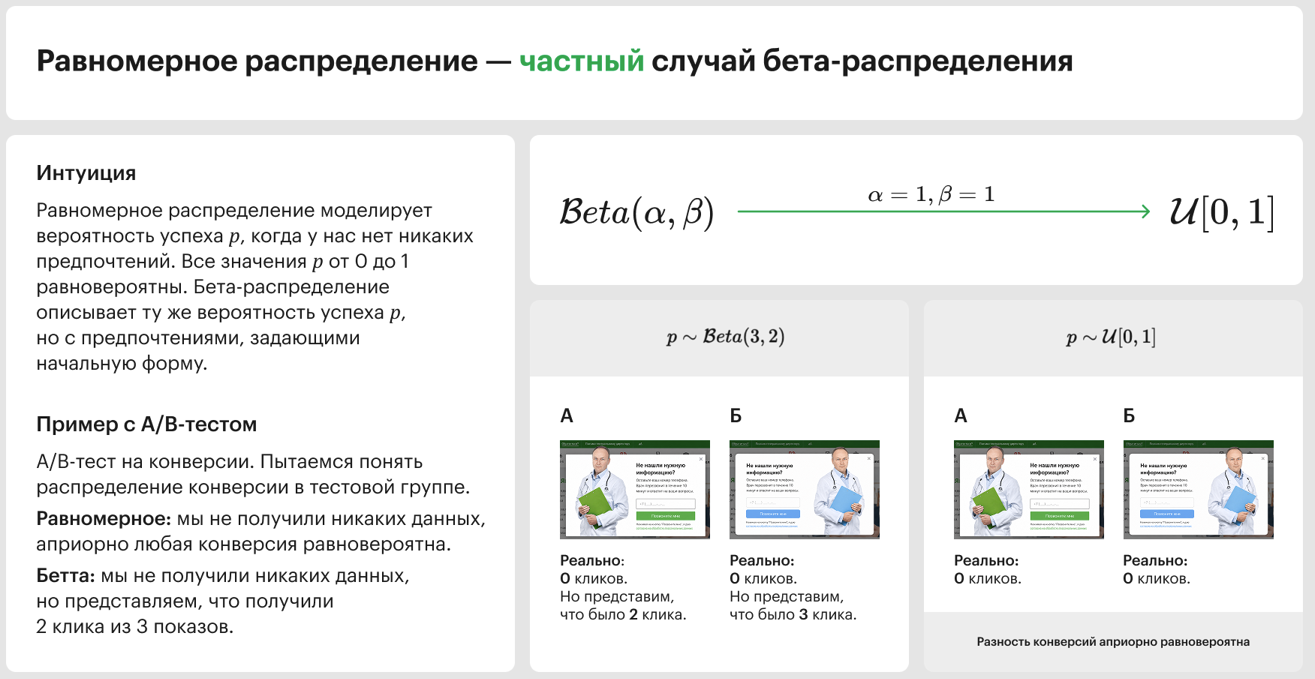

# Задача 5. Retention новых пользователей и бета распределение

В продуктовой аналитике бета-распределение удобно использовать для случайных долей и вероятностей: conversion rate, retention или доли успешных операций. Оно принимает значения только от $0$ до $1$ и может иметь разные формы в зависимости от параметров.

В этой задаче Day 1 retention новой когорты имеет бета-распределение с параметрами:

$$
\alpha = 9
$$

$$
\beta = 5
$$

То есть:

$$
X \sim \operatorname{Beta}(\alpha=9,\beta=5)
$$

До изменения продукта Day 1 retention составлял $60\%$. В новой когорте $10 000$ пользователей. Каждый пользователь, вернувшийся на следующий день, приносит в среднем $300$ рублей выручки.

Нужно:

1. найти вероятность retention выше $75\%$
2. найти вероятность retention от $50\%$ до $70\%$
3. найти интервал между $10$-м и $90$-м процентилями
4. найти медианный уровень retention
5. визуализировать распределение

**Решение**

## Параметры распределения

Параметры $\alpha$ и $\beta$ определяют положение и концентрацию распределения на отрезке от 0 до 1.

Отношение $\alpha$ к сумме $\alpha+\beta$ задаёт среднее значение. Чем больше сумма параметров при том же среднем, тем сильнее распределение сосредоточено около этого среднего.

In [ ]:
from scipy.stats import beta

In [ ]:
alpha_p = 9
beta_p = 5

rv = beta(a=alpha_p, b=beta_p)

## Пункт 1. Вероятность retention выше 75%

Нас интересует событие:

$$
X > 0.75
$$

Функция `sf()` возвращает вероятность оказаться правее заданного порога.

In [ ]:
p_above_75 = rv.sf(0.75)

print("Вероятность retention выше 75%:", round(p_above_75, 4))

Вероятность retention выше 75%: 0.206


Вероятность равна примерно **0.2060**, или **20.60%**.

## Пункт 2. Вероятность retention от 50% до 70%

Нас интересует событие:

$$
0.5 \leq X \leq 0.7
$$

Вероятность на промежутке равна разности накопленных вероятностей:

$$
\mathbb{P}(0.5 \leq X \leq 0.7)
=
F(0.7) - F(0.5)
$$

In [ ]:
p_50_to_70 = rv.cdf(0.7) - rv.cdf(0.5)

print("Вероятность retention от 50% до 70%:", round(p_50_to_70, 4))

Вероятность retention от 50% до 70%: 0.5209


Вероятность равна примерно **0.5209**, или **52.09%**.

## Пункт 3. Интервал между 10-м и 90-м перцентилями

Найдём два порога:

$$
q_{0.1}
\quad \text{и} \quad
q_{0.9}
$$

Ниже 10-го перцентиля находится 10% распределения, а ниже 90-го перцентиля — 90%.

Следовательно, между этими границами находится 80% возможных значений retention.

In [ ]:
lower = rv.ppf(0.10)
upper = rv.ppf(0.90)

print("10-й перцентиль:", round(lower, 4))

print("90-й перцентиль:", round(upper, 4))

10-й перцентиль: 0.4766
90-й перцентиль: 0.7995


10-й перцентиль равен примерно **0.4766**, а 90-й — **0.7995**

80% возможных значений Day 1 retention находятся примерно между **47.66% и 79.95%**

## Пункт 4. Медианный уровень retention

Медиана — это значение $m$, которое делит распределение пополам:

$$
\mathbb{P}(X \leq m) = 0.5
$$

Половина возможных значений retention лежит ниже медианы, половина — выше.

Для нахождения медианы используем функцию `ppf()` с вероятностью $0.5$.

In [ ]:
median_retention = rv.ppf(0.5)

print("Медианный retention:", round(median_retention, 4))

Медианный retention: 0.6498


Медианный retention равен примерно **0.6498**, или **64.98%**.

Он близок к математическому ожиданию, но не обязан с ним совпадать, потому что бета-распределение может быть несимметричным.

## Пункт 5. Визуализация распределения

Построим плотность бета-распределения и выделим область retention выше 75%.

Площадь выделенной области равна вероятности превысить этот уровень.

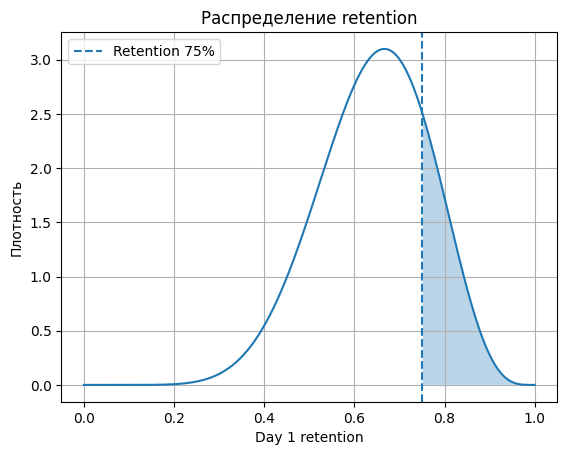

In [ ]:
x = np.linspace(0, 1, 500)
density = rv.pdf(x)

plt.plot(x, density)

selected_x = x[x >= 0.75]
selected_density = rv.pdf(selected_x)

plt.fill_between(
    selected_x,
    selected_density,
    alpha=0.3
)

plt.axvline(
    0.75,
    linestyle="--",
    label="Retention 75%"
)

plt.xlabel("Day 1 retention")
plt.ylabel("Плотность")
plt.title("Распределение retention")
plt.legend()
plt.grid()
plt.show()

# Посмотрим ещё раз на распределения

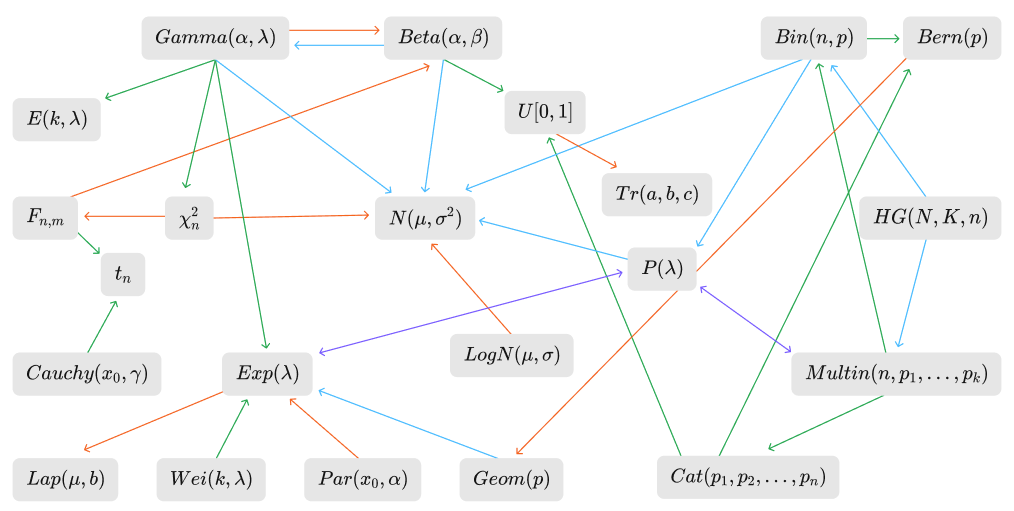

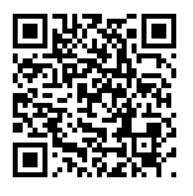